# **NFL Draft Board: A Comprehensive Evaluation of What Makes Collegiate Football Players Successful in the NFL**

**Team**

Nathan Backman (natekbackman) (POC), Chris Marfisi (ChrisMarfisi), Hunter Geise (HunterGeise), Dylan Stafeil (DylanStafeil1), Brett Cerenzio (bjcerenz)


## **Overview**

## **Data**

## **Preprocessing**

## **Modeling**

**We Did some initial modeling with Catboost, Random Forest, & XGBoost on our raw, untransformed variables to get some initial baseline scores for our model. Once we're able to cluster the players effectively to identify similar attributes between players and finalize our dimensionality reduction, these will be used in the final model.**

In [1]:
%%capture
# installing catboost
! pip install catboost

Reading in the Data

In [2]:
%%capture
import pandas as pd, numpy as np, \
seaborn as sns, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('../data/merged.csv', index_col = 0)
merged.head()

This next block of code is filling in NA values with 0, since the data source we read it from doesn't account for 0 stats. Because of this, any stat that's not assigned to a player is effectively 0. This also removes all players that weren't drafted and any players with NA height & weight values. This left us with 790 players in our dataset. We also transformed our y variable (w_av) from a cumulative stat to a rate stat. This is necessary since players who play longer will naturally have higher w_av even though they aren't necessarily better. 

In [3]:
# filling in NAs for counting stats (they should all be zero)
merged.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)

merged.dropna(axis = 0, subset = 'overall', inplace=True)

merged['INT_pct'] = merged['passing_INT']/merged['passing_ATT']

merged.fillna(value={'INT_pct' : 0}, inplace=True)

# Taking yearly average of wAV so players drafted earlier don't have higher values
# since wAV is a cumulative stat
# (in other words, I'm turning it into a rate stat)
merged['adjusted_w_av'] = (merged['w_av']/
 ((merged['last_season'] + 1) - merged['year'])
)

X = merged[['position_x', 'usage_overall', 'avg_ppa_all', 'total_ppa_all','conference',
            'fumbles_FUM', 'fumbles_LOST', 'passing_ATT', 'passing_COMPLETIONS',
            'passing_PCT', 'INT_pct','passing_TD', 'passing_YDS','passing_YPA', 'receiving_REC',
            'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_TD',
            'rushing_YDS', 'rushing_YPC', 'age', 'height', 'weight']]

y = merged['adjusted_w_av'].fillna(value=0)

# Finding NA values in X. Should only be NA values in height & weight.
na_idx = X[X.isna().any(axis=1)].index
print("NA Indexes:", na_idx)

X_nona = X.drop(index=na_idx, inplace = False)
y_nona = y.drop(index=na_idx, inplace=False)

y_nona.shape

NA Indexes: Index([114, 229, 4314, 7510], dtype='int64')


(790,)

In the plots below we can see the distributions of our Y variable both before & after a log transformation. Currently, our y variable is severely right skewed. While a log transformation doesn't completely solve the problem, it does make it look a little more normal.

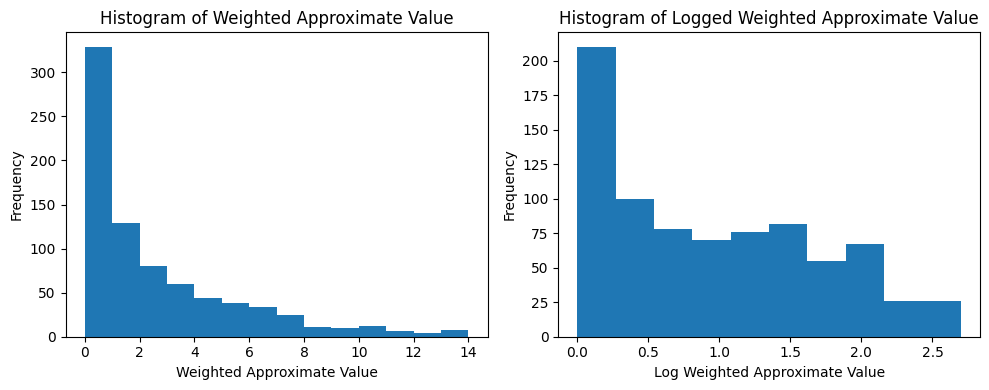

In [4]:
bin_width = 1

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

fig, ax = plt.subplots(1, 2, figsize = (10,4))

ax1 = ax[0]
ax2 = ax[1]

ax1.hist(y_nona, bins = bins)
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Weighted Approximate Value')
ax1.set_title('Histogram of Weighted Approximate Value')

y_log = y_nona.copy()
y_log = np.log(y_log + 1)

bin_width = np.log(2)

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

ax2.hist(y_log)
ax2.set_ylabel('Frequency')
ax2.set_xlabel('Log Weighted Approximate Value')
ax2.set_title('Histogram of Logged Weighted Approximate Value')
plt.tight_layout()
plt.show()

This code helps prepare the data for the Catboost Model. The Catboost model allows us to keep the categorical variables without OneHotEncoding, so we leave them as they are.

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X_nona, y_log, test_size = 0.3)

num_cols = train_x.select_dtypes(include=np.number).columns
cat_cols = train_x.select_dtypes(include=['object', 'str']).columns


# Create transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

# Fit on training data, transform both
train_x = preprocessor.fit_transform(train_x)
test_x = preprocessor.transform(test_x)

This code runs the catboost model, using RMSE as the loss funciton. Here we can see some significant overfitting occuring, as the test RMSE doesn't change after the first 170 iterations while the train data error decreases significantly.

In [6]:
from catboost import CatBoostRegressor

# finds categorical features
cat_features = train_x.select_dtypes(include=['object', 'category', 'str']).columns
cat_indices = [train_x.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    l2_leaf_reg = 10,
    verbose=100,
    random_seed=101
)

model.fit(
    train_x,
    train_y,
    eval_set = (test_x, test_y),
    cat_features=cat_indices # assigns categorical features
)

preds = model.predict(test_x)

0:	learn: 0.7666755	test: 0.7727506	best: 0.7727506 (0)	total: 51.2ms	remaining: 1m 42s
100:	learn: 0.6248576	test: 0.6932259	best: 0.6932259 (100)	total: 372ms	remaining: 6.99s
200:	learn: 0.5519289	test: 0.6823617	best: 0.6819229 (197)	total: 695ms	remaining: 6.22s
300:	learn: 0.4927240	test: 0.6827751	best: 0.6807384 (269)	total: 1s	remaining: 5.67s
400:	learn: 0.4461586	test: 0.6858694	best: 0.6807384 (269)	total: 1.32s	remaining: 5.29s
500:	learn: 0.4117853	test: 0.6883809	best: 0.6807384 (269)	total: 1.65s	remaining: 4.92s
600:	learn: 0.3796187	test: 0.6879912	best: 0.6807384 (269)	total: 1.97s	remaining: 4.58s
700:	learn: 0.3520793	test: 0.6897272	best: 0.6807384 (269)	total: 2.37s	remaining: 4.39s
800:	learn: 0.3287976	test: 0.6911353	best: 0.6807384 (269)	total: 2.81s	remaining: 4.21s
900:	learn: 0.3052606	test: 0.6928763	best: 0.6807384 (269)	total: 3.46s	remaining: 4.22s
1000:	learn: 0.2853882	test: 0.6950473	best: 0.6807384 (269)	total: 3.83s	remaining: 3.82s
1100:	learn: 0

After transforming the predictions back to their actual scale, we get an RMSE of 2.83.

In [7]:
from sklearn.metrics import root_mean_squared_error as rmse
preds_exp = np.exp(preds) - 1
test_y_exp = np.exp(test_y) - 1

test_rmse = rmse(test_y_exp, preds_exp)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 2.69


Looking at this histogram comparing the predicted values & the actual values, it seems the predictions don't predict high enough.

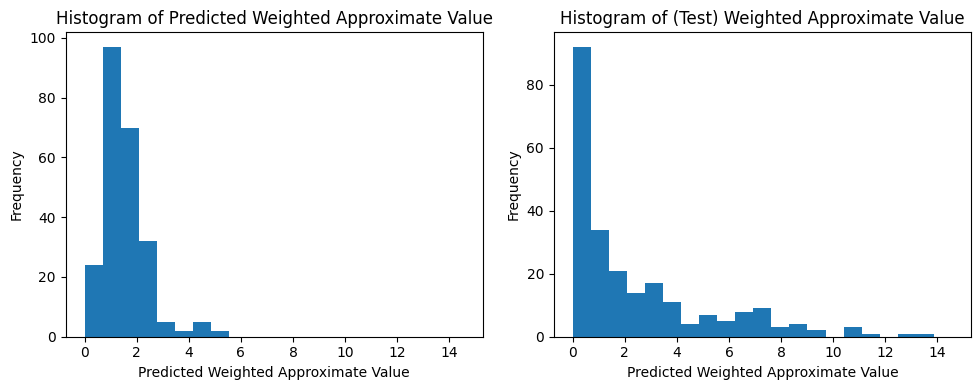

In [8]:
fig, ax = plt.subplots(1,2,figsize = (10,4))

ax1 = ax[0]
ax2 = ax[1]

ax1.hist(preds_exp, bins = bins)
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Predicted Weighted Approximate Value')
ax1.set_title('Histogram of Predicted Weighted Approximate Value')

ax2.hist(test_y_exp, bins = bins)
ax2.set_ylabel('Frequency')
ax2.set_xlabel('Predicted Weighted Approximate Value')
ax2.set_title('Histogram of (Test) Weighted Approximate Value')

plt.tight_layout()
plt.show()

This code below performs 10-fold cross-validation with CatBoost. This gives us an RMSE of 2.67.

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include=['object', 'str']).columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original) # Apply StandardScaler to numerical columns
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category', 'str']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = CatBoostRegressor(
        iterations=2000,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=1000,
        l2_leaf_reg = 10,
        random_seed=101 # Added random_seed for reproducibility
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = (X_val_processed, y_val_fold),
        cat_features=cat_indices_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

0:	learn: 0.7615862	test: 0.8176041	best: 0.8176041 (0)	total: 6.01ms	remaining: 12s
1000:	learn: 0.3062265	test: 0.7367422	best: 0.7231914 (173)	total: 4.24s	remaining: 4.23s
1999:	learn: 0.1839003	test: 0.7409859	best: 0.7231914 (173)	total: 11.6s	remaining: 0us

bestTest = 0.7231913745
bestIteration = 173

Shrink model to first 174 iterations.
0:	learn: 0.7641433	test: 0.8024851	best: 0.8024851 (0)	total: 9.27ms	remaining: 18.5s
1000:	learn: 0.3133638	test: 0.7354668	best: 0.7345717 (790)	total: 4.53s	remaining: 4.52s
1999:	learn: 0.1841648	test: 0.7317029	best: 0.7314573 (1794)	total: 8.55s	remaining: 0us

bestTest = 0.7314572866
bestIteration = 1794

Shrink model to first 1795 iterations.
0:	learn: 0.7684157	test: 0.7630714	best: 0.7630714 (0)	total: 7.04ms	remaining: 14.1s
1000:	learn: 0.3174315	test: 0.6941698	best: 0.6836515 (203)	total: 4.17s	remaining: 4.16s
1999:	learn: 0.1761649	test: 0.7067326	best: 0.6836515 (203)	total: 7.94s	remaining: 0us

bestTest = 0.6836514752
bestI

This code runs the same code as above except now it's using a RandomForestRegressor instead of CatBoost. This gives us a RMSE of 2.75. 

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include=['object', 'str']).columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    model = RandomForestRegressor(
        n_estimators = 1000,
        max_features = 'sqrt'
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

CV RMSE: 2.75


Finally, we do the same thing with XGBoost. This gives us an RMSE of 2.75.

In [13]:
%%capture
! pip install xgboost

In [ ]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []


num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include=['object', 'str']).columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Creates a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    model = XGBRegressor(
        n_estimators = 1000,
        objective = 'reg:squarederror',
        learning_rate = 0.05,
        max_depth = 6,
        random_state = 101,
        reg_lambda = 5,
        eval_metric = 'rmse'
    )

    print(f"{"="*30}New Fold{"="*30}")

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = [(X_val_processed, y_val_fold)],
        verbose = 1000
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

==============================New Fold==============================
[0]	validation_0-rmse:0.81638
[999]	validation_0-rmse:0.76985
==============================New Fold==============================
[0]	validation_0-rmse:0.80013
[999]	validation_0-rmse:0.78804
==============================New Fold==============================
[0]	validation_0-rmse:0.75967
[999]	validation_0-rmse:0.75287
==============================New Fold==============================
[0]	validation_0-rmse:0.72359
[999]	validation_0-rmse:0.72237
==============================New Fold==============================
[0]	validation_0-rmse:0.74848
[999]	validation_0-rmse:0.70161
==============================New Fold==============================
[0]	validation_0-rmse:0.72682
[999]	validation_0-rmse:0.67907
==============================New Fold==============================
[0]	validation_0-rmse:0.82438
[999]	validation_0-rmse:0.75349
==============================New Fold==============================
[0]	validation

**We're also looking to add Instance-Based Uncertainty Estimation (IBUG) to our final model to create a probabilistic distribution of estimates rather than just a single point estimate.**

## **Problems & Challenges**

## **Next Steps**